In [1]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import geobr
import geopandas as gpd
import matplotlib as mpl

# Métodos

In [31]:
def delete_hdf_table(file_path, key):
    with pd.HDFStore(file_path, mode='a') as store:
        if f'/{key}' in store.keys():
            store.remove(f'/{key}')
            print(f"Table '{key}' removed from HDF5.")
        else:
            print(f"Table '{key}' not found in HDF5.")

def read_hdf(file_path, key):
    return pd.read_hdf(file_path, mode = 'r', key=key, encoding='utf-8')

def show_hdf_tables(file_path):
    with pd.HDFStore(file_path) as store:
        keys = store.keys()
        print(f"Current tables in {file_path}:")
        for key in keys:
            print(f"  - {key.lstrip('/')}")

def write_hdf_chunks(df, path, key, chunksize=10_000_000):
    with pd.HDFStore(path, mode='a', complevel=9, complib='blosc:lz4') as store: # Open in read+write mode to append
        for i in range(0, len(df), chunksize):
            chunk = df.iloc[i:i+chunksize]
            append_mode = i != 0 # Append after the first chunk to avoid overwriting data from previous chunks
            store.append(
                key,
                chunk,
                format='table',
                data_columns=True,
                min_itemsize={'gauge_code': 20},
                encoding='utf-8',
                append=append_mode
            )
            del chunk  # free memory
            print(f"Written rows {i} to {min(i+chunksize-1, len(df))}")

def read_hdf_chunks(file_path, key, chunksize=1_000_000):
    """
    Read HDF file in chunks and concatenate into a single DataFrame.
    Only works if the HDF key is stored in 'table' format.
    
    Parameters:
    file_path (str): Path to the HDF5 file
    key (str): Key/table name to read
    chunksize (int): Number of rows per chunk
    
    Returns:
    pd.DataFrame: Concatenated DataFrame
    """
    try:
        with pd.HDFStore(file_path, mode='r+') as store:  # Changed to 'r+' (read/write) and automatically closes the store
            if store.get_storer(key).is_table:
                dfs = []
                i = 1
                for chunk in store.select(key, chunksize=chunksize):
                    dfs.append(chunk)
                    print(f"Chunk {i} with {len(chunk)} rows read.")
                    i += 1                
                if dfs:  # Check if any chunks were read
                    return pd.concat(dfs, ignore_index=True)
                else:
                    print("No data found or chunksize too large.")
                    return pd.DataFrame()
            else:
                # If not table format, read all at once
                print("Not in table format, reading all data at once.")
                return store.select(key)  # Convert to DataFrame
    except FileNotFoundError:
        print(f"File {file_path} not found.")
        return pd.DataFrame()
    except KeyError:
        print(f"Key {key} not found in file {file_path}.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error reading HDF file: {e}")
        return pd.DataFrame()




def calculate_quality_label(row):
    if row['quality_index'] >= 90 and row['p_availability'] >= 99:
        return '1 - Excellent Quality'
    elif row['quality_index'] >= 85 and row['p_availability'] >= 95:
        return '2 - Good Quality'
    elif row['quality_index'] >= 80 and row['p_availability'] >= 90:
        return '3 - Acceptable Quality'
    elif row['quality_index'] >= 50:
        return '4 - Low Quality'
    else:
        return '5 - Very Low Quality'

# Parâmetros

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['axes.grid'] = False
plt.rcParams['font.size'] = '14'
plt.rcParams["font.family"] = "Times New Roman" 

In [4]:
file_path = './1 - Organized data gauge/BRAZIL/DATASETS/BRAZIL_DAILY_1961_2024_CLEANED.h5' 

In [6]:
show_hdf_tables(file_path)

Current tables in ./1 - Organized data gauge/BRAZIL/DATASETS/BRAZIL_DAILY_1961_2024_CLEANED.h5:
  - table_data
  - table_data_outlier_filtered
  - table_info
  - table_outlier
  - table_outlier_filter_1
  - table_outlier_filter_1_export
  - table_outlier_filter_2_export
  - table_p_availability
  - table_preclassif
  - table_q1_gaps
  - table_q2_week
  - table_q3_outliers
  - table_qc_info


In [7]:
# df_p_availability = pd.read_hdf(file_path, key = 'table_p_availability', encoding = 'utf-8')
# df_q1_gaps = pd.read_hdf(file_path, key = 'table_q1_gaps', encoding = 'utf-8')
# df_q2_week = pd.read_hdf(file_path, key = 'table_q2_week', encoding = 'utf-8')
# df_q3_outliers = pd.read_hdf(file_path, key = 'table_q3_outliers', encoding = 'utf-8')
# df_preclassif = pd.read_hdf(file_path, key = 'table_preclassif', encoding = 'utf-8')
# df_info = pd.read_hdf(file_path, key = 'table_info', encoding = 'utf-8')


df_p_availability = read_hdf(file_path, key = 'table_p_availability')
df_q1_gaps = read_hdf(file_path, key = 'table_q1_gaps')
df_q2_week = read_hdf(file_path, key = 'table_q2_week')
df_q3_outliers = read_hdf(file_path, key = 'table_q3_outliers')
df_preclassif = read_hdf(file_path, key = 'table_preclassif')
df_info = read_hdf(file_path, key = 'table_info')


df_preclassif

,gauge_code,year,annual_rainfall_mm,active_days,consecutive_dry_days,preclassif
0,00047000,1961,2186.0,365,275,LQ
1,00047000,1962,273.8,365,153,LQ
2,00047000,1963,686.2,365,115,
3,00047000,1964,597.5,366,145,
4,00047002,1977,133.4,23,6,LQ
...,...,...,...,...,...,...
345863,S713,2021,76.2,365,150,LQ
345864,S714,2021,828.0,365,75,
345865,S715,2021,1041.8,365,76,
345866,S716,2021,928.8,365,68,


In [8]:
df_qc_info = pd.merge(df_preclassif
                      , df_p_availability
                      , on = ['gauge_code', 'year']
                      , how='outer').merge(df_q1_gaps
                                          , on = ['gauge_code', 'year']
                                          , how='outer').merge(df_q2_week
                                                              , on = ['gauge_code', 'year']
                                                              , how='outer').merge(df_q3_outliers
                                                                                  , on = ['gauge_code', 'year']
                                                                                  , how='outer')
df_qc_info.fillna(0, inplace=True)
df_qc_info

,gauge_code,year,annual_rainfall_mm,active_days,consecutive_dry_days,preclassif,p_availability,q1_gaps,q2_week,q3_outliers
0,00047000,1961,2186.0,365,275,LQ,100.00000,100.0,71.803161,98.082192
1,00047000,1962,273.8,365,153,LQ,100.00000,100.0,69.402386,99.452055
2,00047000,1963,686.2,365,115,,100.00000,100.0,66.650234,99.726027
3,00047000,1964,597.5,366,145,,100.00000,100.0,87.798731,99.726776
4,00047002,1977,133.4,23,6,LQ,6.30137,0.0,6.458565,91.304348
...,...,...,...,...,...,...,...,...,...,...
345863,S713,2021,76.2,365,150,LQ,100.00000,100.0,62.583426,99.452055
345864,S714,2021,828.0,365,75,,100.00000,100.0,65.175174,98.082192
345865,S715,2021,1041.8,365,76,,100.00000,100.0,78.359308,97.808219
345866,S716,2021,928.8,365,68,,100.00000,100.0,77.324050,98.904110


In [9]:
df_qc_info['quality_index'] = (df_qc_info['p_availability'] + df_qc_info['q1_gaps'] + df_qc_info['q2_week'] + df_qc_info['q3_outliers'])/4
df_qc_info.describe()

,year,annual_rainfall_mm,active_days,consecutive_dry_days,p_availability,q1_gaps,q2_week,q3_outliers,quality_index
count,345868.000000,345868.000000,345868.000000,345868.000000,345868.000000,345868.000000,345868.000000,345868.000000,345868.000000
mean,1992.056756,1197.368872,357.349737,85.129662,97.832938,96.307587,70.122931,98.651093,90.728637
std,17.912871,704.035588,43.049697,92.824667,11.799340,18.335404,23.131221,1.294597,10.046643
min,1961.000000,0.000000,1.000000,0.000000,0.273224,0.000000,0.000000,0.000000,0.068306
25%,1977.000000,724.000000,365.000000,25.000000,100.000000,100.000000,67.725139,98.082192,91.304793
50%,1991.000000,1211.800000,365.000000,46.000000,100.000000,100.000000,77.576796,98.904110,93.959770
75%,2007.000000,1600.600000,365.000000,107.000000,100.000000,100.000000,83.634528,99.452055,95.458863
max,2024.000000,23031.000000,366.000000,366.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [10]:
df_qc_info['quality_label'] = df_qc_info.apply(calculate_quality_label, axis=1)
df_qc_info = pd.merge(df_info, df_qc_info, on = 'gauge_code', how='outer')
df_qc_info

,gauge_code,state,city,name_station,lat,long,responsible,source,state_abbreviation,year,annual_rainfall_mm,active_days,consecutive_dry_days,preclassif,p_availability,q1_gaps,q2_week,q3_outliers,quality_index,quality_label
0,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1961,2186.0,365,275,LQ,100.00000,100.0,71.803161,98.082192,92.471338,1 - Excellent Quality
1,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1962,273.8,365,153,LQ,100.00000,100.0,69.402386,99.452055,92.213610,1 - Excellent Quality
2,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1963,686.2,365,115,,100.00000,100.0,66.650234,99.726027,91.594065,1 - Excellent Quality
3,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1964,597.5,366,145,,100.00000,100.0,87.798731,99.726776,96.881377,1 - Excellent Quality
4,00047002,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.623100,-47.353600,ANA,HIDROWEB,PA,1977,133.4,23,6,LQ,6.30137,0.0,6.458565,91.304348,26.016071,5 - Very Low Quality
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345863,S713,MATO GROSSO DO SUL,NOVA ANDRADINA,NOVA ANDRADINA | S713,-22.078611,-53.465833,INMET,INMET,MS,2021,76.2,365,150,LQ,100.00000,100.0,62.583426,99.452055,90.508870,1 - Excellent Quality
345864,S714,MATO GROSSO DO SUL,PEDRO GOMES,PEDRO GOMES | S714,-18.072778,-54.548889,INMET,INMET,MS,2021,828.0,365,75,,100.00000,100.0,65.175174,98.082192,90.814342,1 - Excellent Quality
345865,S715,MATO GROSSO DO SUL,RIBAS DO RIO PARDO,RIBAS DO RIO PARDO | S715,-20.466694,-53.763028,INMET,INMET,MS,2021,1041.8,365,76,,100.00000,100.0,78.359308,97.808219,94.041882,1 - Excellent Quality
345866,S716,MATO GROSSO DO SUL,SANTA RITA DO PARDO,SANTA RITA DO PARDO | S716,-21.305889,-52.820375,INMET,INMET,MS,2021,928.8,365,68,,100.00000,100.0,77.324050,98.904110,94.057040,1 - Excellent Quality


In [11]:
# Count rows grouped by 'quality_label'
qc_count = df_qc_info.groupby('quality_label').size().reset_index(name='count')

print(qc_count)

#           quality_label                 count
# 0         1 - Excellent Quality         277322
# 1         2 - Good Quality               24970
# 2         3 - Acceptable Quality          5993
# 3         4 - Low Quality                31323
# 4         5 - Very Low Quality            6421


            quality_label   count
0   1 - Excellent Quality  277297
1        2 - Good Quality   24993
2  3 - Acceptable Quality    5979
3         4 - Low Quality   31300
4    5 - Very Low Quality    6299


In [12]:
# Create a dictionary with state abbreviations and corresponding regions in English
state_region_dict = {
    'AC': 'North', 'AL': 'Northeast', 'AP': 'North', 'AM': 'North', 'BA': 'Northeast',
    'CE': 'Northeast', 'DF': 'Central-West', 'ES': 'Southeast', 'GO': 'Central-West',
    'MA': 'Northeast', 'MT': 'Central-West', 'MS': 'Central-West', 'MG': 'Southeast',
    'PA': 'North', 'PB': 'Northeast', 'PR': 'South', 'PE': 'Northeast', 'PI': 'Northeast',
    'RJ': 'Southeast', 'RN': 'Northeast', 'RS': 'South', 'RO': 'North', 'RR': 'North',
    'SC': 'South', 'SP': 'Southeast', 'SE': 'Northeast', 'TO': 'North'
}

# Map the regions to the df_qc_info dataframe
df_qc_info['region'] = df_qc_info['state_abbreviation'].map(state_region_dict)
df_qc_info

,gauge_code,state,city,name_station,lat,long,responsible,source,state_abbreviation,year,...,active_days,consecutive_dry_days,preclassif,p_availability,q1_gaps,q2_week,q3_outliers,quality_index,quality_label,region
0,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1961,...,365,275,LQ,100.00000,100.0,71.803161,98.082192,92.471338,1 - Excellent Quality,North
1,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1962,...,365,153,LQ,100.00000,100.0,69.402386,99.452055,92.213610,1 - Excellent Quality,North
2,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1963,...,365,115,,100.00000,100.0,66.650234,99.726027,91.594065,1 - Excellent Quality,North
3,00047000,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.650000,-47.550000,INMET,HIDROWEB,PA,1964,...,366,145,,100.00000,100.0,87.798731,99.726776,96.881377,1 - Excellent Quality,North
4,00047002,PARÁ,SALINÓPOLIS,SALINÓPOLIS,-0.623100,-47.353600,ANA,HIDROWEB,PA,1977,...,23,6,LQ,6.30137,0.0,6.458565,91.304348,26.016071,5 - Very Low Quality,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345863,S713,MATO GROSSO DO SUL,NOVA ANDRADINA,NOVA ANDRADINA | S713,-22.078611,-53.465833,INMET,INMET,MS,2021,...,365,150,LQ,100.00000,100.0,62.583426,99.452055,90.508870,1 - Excellent Quality,Central-West
345864,S714,MATO GROSSO DO SUL,PEDRO GOMES,PEDRO GOMES | S714,-18.072778,-54.548889,INMET,INMET,MS,2021,...,365,75,,100.00000,100.0,65.175174,98.082192,90.814342,1 - Excellent Quality,Central-West
345865,S715,MATO GROSSO DO SUL,RIBAS DO RIO PARDO,RIBAS DO RIO PARDO | S715,-20.466694,-53.763028,INMET,INMET,MS,2021,...,365,76,,100.00000,100.0,78.359308,97.808219,94.041882,1 - Excellent Quality,Central-West
345866,S716,MATO GROSSO DO SUL,SANTA RITA DO PARDO,SANTA RITA DO PARDO | S716,-21.305889,-52.820375,INMET,INMET,MS,2021,...,365,68,,100.00000,100.0,77.324050,98.904110,94.057040,1 - Excellent Quality,Central-West


In [13]:
df_qc_info['final_classif'] = df_qc_info.apply(
    lambda row: 'LQ' if row['preclassif'] == 'LQ' or row['quality_label'] in ['4 - Low Quality', '5 - Very Low Quality'] else 'HQ',
    axis=1
)
df_qc_info[['preclassif', 'quality_label', 'final_classif']]

,preclassif,quality_label,final_classif
0,LQ,1 - Excellent Quality,LQ
1,LQ,1 - Excellent Quality,LQ
2,,1 - Excellent Quality,HQ
3,,1 - Excellent Quality,HQ
4,LQ,5 - Very Low Quality,LQ
...,...,...,...
345863,LQ,1 - Excellent Quality,LQ
345864,,1 - Excellent Quality,HQ
345865,,1 - Excellent Quality,HQ
345866,,1 - Excellent Quality,HQ


In [14]:
# df_qc_info.to_hdf(file_path, key='table_qc_info', mode='r+', encoding='utf-8', append=False, complevel=9, format='table')
write_hdf_chunks(df_qc_info, file_path, key='table_qc_info', chunksize=10_000_000)

Written rows 0 to 345868


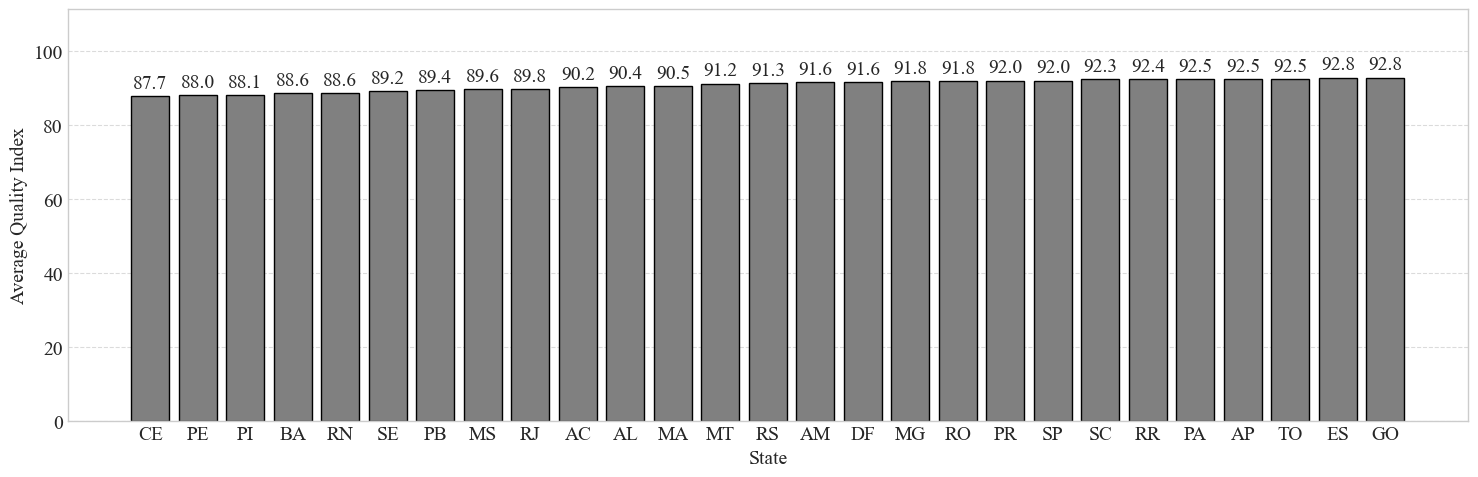

In [15]:
# Calculate the average quality index by state_abbreviation
df_avg_quality_by_state = df_qc_info.groupby('state_abbreviation')['quality_index'].mean().reset_index()
df_avg_quality_by_state['quality_index'] = df_avg_quality_by_state['quality_index'].round(1)
df_avg_quality_by_state.sort_values('quality_index', ascending=True, inplace=True)

# Create a figure and axis with a custom size
fig, ax = plt.subplots(figsize=(15, 5))

# Plot the bar chart
bars = ax.bar(df_avg_quality_by_state['state_abbreviation'], df_avg_quality_by_state['quality_index'], color='grey', edgecolor='black')
ax.set_ylim(0, df_avg_quality_by_state['quality_index'].max() * 1.2)

# Add labels, title, and grid
ax.set_xlabel('State')
ax.set_ylabel('Average Quality Index')
# ax.set_title('Average Quality Index by State')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points", 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [16]:
# Calculate the overall average and standard deviation of quality index
overall_avg_quality = df_avg_quality_by_state['quality_index'].mean()
std_quality_index = df_avg_quality_by_state['quality_index'].std()

# Define a threshold for statistical significance (e.g., 1 standard deviation from the mean)
threshold = std_quality_index * 3 # You can adjust this value as needed

# Calculate the difference from the overall average for each state
df_avg_quality_by_state['difference'] = df_avg_quality_by_state['quality_index'] - overall_avg_quality

# Mark states with significant difference (absolute difference > threshold)
df_avg_quality_by_state['significant_difference'] = df_avg_quality_by_state['difference'].abs() > threshold

df_avg_quality_by_state

,state_abbreviation,quality_index,difference,significant_difference
5,CE,87.7,-3.085185,False
15,PE,88.0,-2.785185,False
16,PI,88.1,-2.685185,False
4,BA,88.6,-2.185185,False
19,RN,88.6,-2.185185,False
24,SE,89.2,-1.585185,False
14,PB,89.4,-1.385185,False
11,MS,89.6,-1.185185,False
18,RJ,89.8,-0.985185,False
0,AC,90.2,-0.585185,False


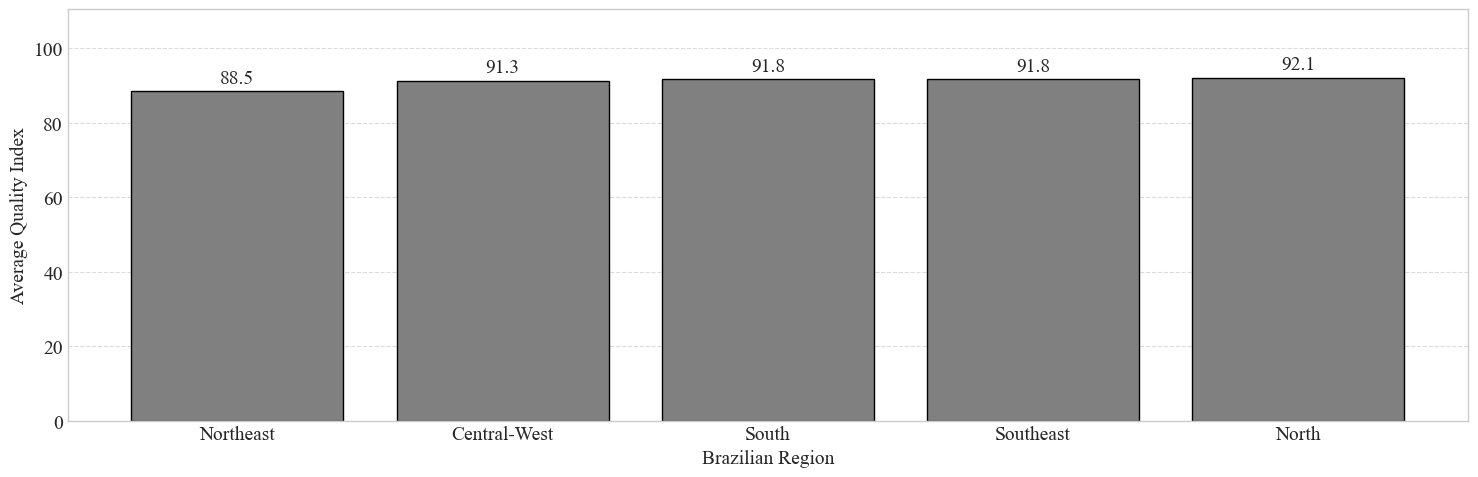

In [17]:
# Calculate the average quality index by region
df_avg_quality_by_region = df_qc_info.groupby('region')['quality_index'].mean().reset_index()
df_avg_quality_by_region['quality_index'] = df_avg_quality_by_region['quality_index'].round(1)
df_avg_quality_by_region.sort_values('quality_index', ascending=True, inplace=True)

# Create a figure and axis with a custom size
fig, ax = plt.subplots(figsize=(15, 5))

# Plot the bar chart
bars = ax.bar(df_avg_quality_by_region['region'], df_avg_quality_by_region['quality_index'], color='grey', edgecolor='black')
ax.set_ylim(0, df_avg_quality_by_region['quality_index'].max() * 1.2)

# Add labels, title, and grid
ax.set_xlabel('Brazilian Region')
ax.set_ylabel('Average Quality Index')
# ax.set_title('Average Quality Index by Region')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points", 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

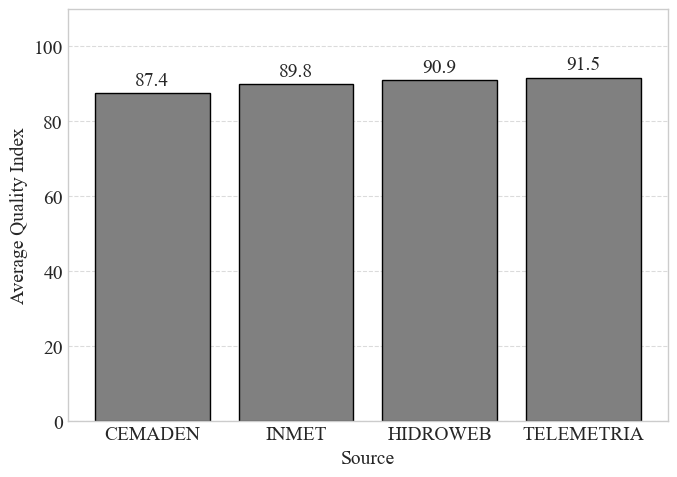

In [18]:
# Calculate the average quality index by source
df_avg_quality_by_source = df_qc_info.groupby('source')['quality_index'].mean().reset_index()
df_avg_quality_by_source['quality_index'] = df_avg_quality_by_source['quality_index'].round(1)
df_avg_quality_by_source.sort_values('quality_index', ascending=True, inplace=True)

# Create a figure and axis with a custom size
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the bar chart
bars = ax.bar(df_avg_quality_by_source['source'], df_avg_quality_by_source['quality_index'], color='grey', edgecolor='black')
ax.set_ylim(0, df_avg_quality_by_source['quality_index'].max() * 1.2)

# Add labels, title, and grid
ax.set_xlabel('Source')
ax.set_ylabel('Average Quality Index')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points", 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [19]:
br_map = geobr.read_state(year = 2020)
br_map.crs = "EPSG:4326"
br_map['name_state'] = br_map['name_state'].apply(str.upper)
br_map = br_map.sort_values(by = ['name_state'])
br_map['name_state'].replace({'AMAZÔNAS': 'AMAZONAS'}, inplace = True)
br_map.head()

C:\Users\linde\AppData\Local\Temp\ipykernel_35280\948283981.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  br_map['name_state'].replace({'AMAZÔNAS': 'AMAZONAS'}, inplace = True)


,code_state,abbrev_state,name_state,code_region,name_region,geometry
1,12.0,AC,ACRE,1.0,Norte,"MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ..."
13,27.0,AL,ALAGOAS,2.0,Nordeste,"MULTIPOLYGON (((-35.75791 -9.69285, -35.75801 ..."
5,16.0,AP,AMAPÁ,1.0,Norte,"MULTIPOLYGON (((-50.45011 2.10924, -50.44715 2..."
2,13.0,AM,AMAZONAS,1.0,Norte,"MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ..."
15,29.0,BA,BAHIA,2.0,Nordeste,"MULTIPOLYGON (((-38.69616 -17.97901, -38.69618..."


In [20]:
br_map_count = br_map.merge(df_avg_quality_by_state, left_on='abbrev_state', right_on='state_abbreviation', how='left')
br_map_count = br_map_count.sort_values(by = ['name_state'])
br_map_count = gpd.GeoDataFrame(br_map_count)
br_map_count['centroid'] = gpd.GeoSeries(br_map_count['geometry']).centroid
br_map_count = gpd.GeoDataFrame(br_map_count)
br_map_count

C:\Users\linde\AppData\Local\Temp\ipykernel_35280\326786035.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  br_map_count['centroid'] = gpd.GeoSeries(br_map_count['geometry']).centroid


,code_state,abbrev_state,name_state,code_region,name_region,geometry,state_abbreviation,quality_index,difference,significant_difference,centroid
0,12.0,AC,ACRE,1.0,Norte,"MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ...",AC,90.2,-0.585185,False,POINT (-70.47293 -9.21327)
1,27.0,AL,ALAGOAS,2.0,Nordeste,"MULTIPOLYGON (((-35.75791 -9.69285, -35.75801 ...",AL,90.4,-0.385185,False,POINT (-36.62485 -9.51367)
2,16.0,AP,AMAPÁ,1.0,Norte,"MULTIPOLYGON (((-50.45011 2.10924, -50.44715 2...",AP,92.5,1.714815,False,POINT (-51.96202 1.44746)
3,13.0,AM,AMAZONAS,1.0,Norte,"MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ...",AM,91.6,0.814815,False,POINT (-64.65309 -4.1541)
4,29.0,BA,BAHIA,2.0,Nordeste,"MULTIPOLYGON (((-38.69616 -17.97901, -38.69618...",BA,88.6,-2.185185,False,POINT (-41.72116 -12.47533)
5,23.0,CE,CEARÁ,2.0,Nordeste,"MULTIPOLYGON (((-41.18292 -4.01797, -41.18552 ...",CE,87.7,-3.085185,False,POINT (-39.61579 -5.09322)
6,53.0,DF,DISTRITO FEDERAL,5.0,Centro Oeste,"MULTIPOLYGON (((-47.41734 -15.54655, -47.4172 ...",DF,91.6,0.814815,False,POINT (-47.79685 -15.78117)
7,32.0,ES,ESPÍRITO SANTO,3.0,Sudeste,"MULTIPOLYGON (((-40.75189 -20.92722, -40.75193...",ES,92.8,2.014815,False,POINT (-40.66851 -19.57518)
8,52.0,GO,GOIÁS,5.0,Centro Oeste,"MULTIPOLYGON (((-52.36102 -16.0816, -52.3604 -...",GO,92.8,2.014815,False,POINT (-49.62251 -16.04119)
9,21.0,MA,MARANHÃO,2.0,Nordeste,"MULTIPOLYGON (((-44.9662 -1.27114, -44.96081 -...",MA,90.5,-0.285185,False,POINT (-45.28777 -5.07221)


C:\Users\linde\AppData\Local\Temp\ipykernel_35280\2234521622.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(br_map_count.centroid.x, br_map_count.centroid.y, br_map_count.quality_index):


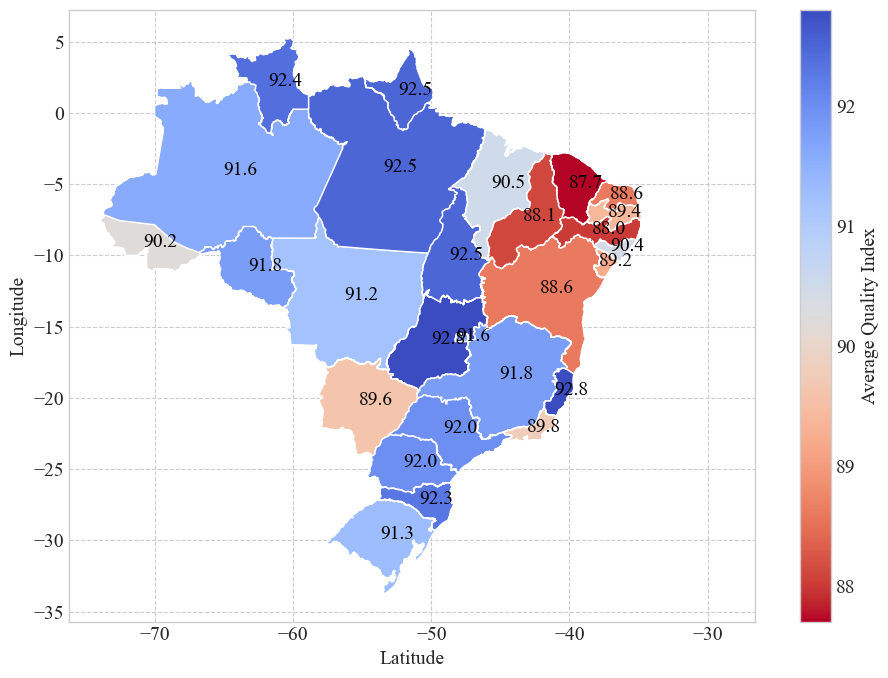

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
br_map_count.plot(ax=ax, edgecolor='white', column='quality_index', legend=False, cmap='coolwarm_r', alpha=1.0)
# ax.set_title("Average Quality Index by Brazilian state", fontsize=14, fontname="Times New Roman")

# Adding labels to each point
for x, y, label in zip(br_map_count.centroid.x, br_map_count.centroid.y, br_map_count.quality_index):
    ax.annotate(label, xy=(x, y), xytext=(-4, -2), textcoords="offset points", color="black", rotation=0)

# Adding colorbar
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(br_map_count['quality_index'].min(), br_map_count['quality_index'].max()), cmap='coolwarm_r'),
             ax=ax, orientation='vertical', label='Average Quality Index')

# ax.set_ylim([-35, 7])
# ax.set_xlim([-75, -33])
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.grid(ls='--')
plt.tight_layout()
plt.savefig('./figures/average_quality_index_by_state_1961_2024.jpeg', format='jpeg', dpi=1200, transparent=False, bbox_inches=None)
plt.show()
plt.close()

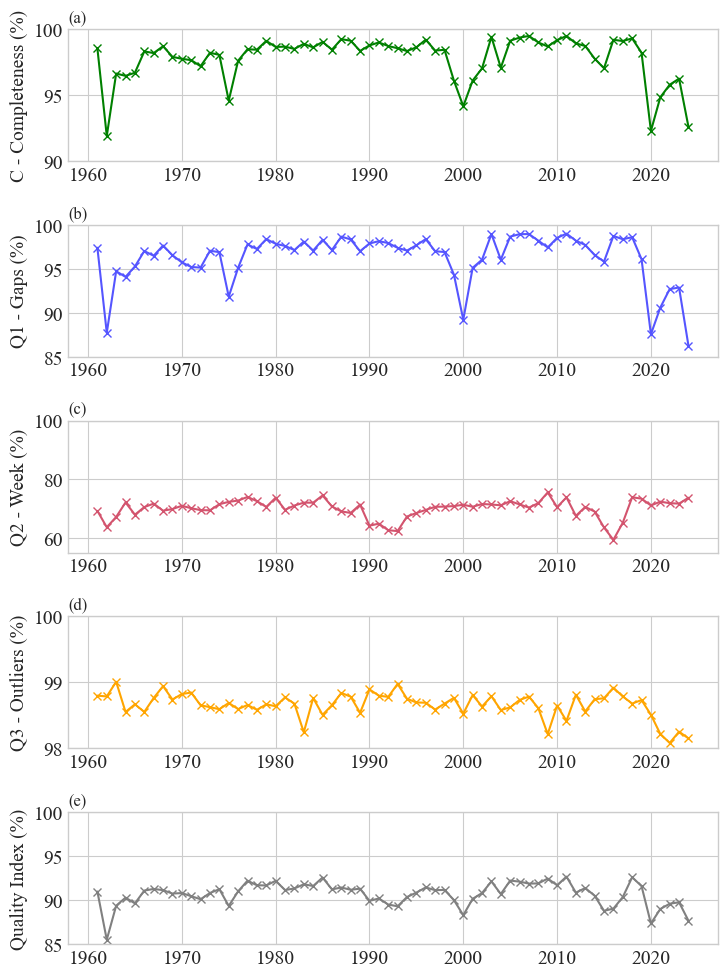

In [22]:
# Calcular a média anual de cada parâmetro
df_avg_params = df_qc_info.groupby('year').agg({
    'p_availability': 'mean',
    'q1_gaps': 'mean',
    'q2_week': 'mean',
    'q3_outliers': 'mean',
    'quality_index': 'mean'
}).reset_index()

# Criar figura e eixos
fig, ax = plt.subplots(5, 1, figsize=(7.5, 10), sharex=True)

# (a) C - Completeness
ax0 = ax[0]
ax0.plot(df_avg_params['year'], df_avg_params['p_availability'], marker='x', color='g', label='C - Completeness (%)')
ax0.set_ylim(90, 100)
ax0.set_ylabel('C - Completeness (%)')
ax0.grid(True)

# (b) Q1 - Gaps
ax1 = ax[1]
ax1.plot(df_avg_params['year'], df_avg_params['q1_gaps'], marker='x', color='#5555ff', label='Q1 - Gaps (%)')
ax1.set_ylabel('Q1 - Gaps (%)')
ax1.set_ylim(85, 100)
ax1.grid(True)

# (c) Q2 - Week
ax2 = ax[2]
ax2.plot(df_avg_params['year'], df_avg_params['q2_week'], marker='x', color='#d3546e', label='Q2 - Week (%)')
ax2.set_ylabel('Q2 - Week (%)')
ax2.set_ylim(55, 100)
ax2.grid(True)

# (d) Q3 - Outliers
ax3 = ax[3]
ax3.plot(df_avg_params['year'], df_avg_params['q3_outliers'], marker='x', color='orange', label='Q3 - Outliers (%)')
ax3.set_ylim(98, 100)
ax3.set_ylabel('Q3 - Outliers (%)')
ax3.grid(True)

# (e) Quality Index
ax4 = ax[4]
ax4.set_ylim(85, 100)
ax4.plot(df_avg_params['year'], df_avg_params['quality_index'], marker='x', color='grey', label='Quality Index (%)')
ax4.set_ylabel('Quality Index (%)')
ax4.grid(True)

# Mostrar ticks no eixo x em todos os subplots
for a in ax:
    a.label_outer()
    a.tick_params(axis='x', which='both', labelbottom=True)

# Adicionar letras (a)–(e) nos cantos superiores esquerdos de cada gráfico
letters = ['a', 'b', 'c', 'd', 'e']
for i, a in enumerate(ax):
    a.text(0.001, 1.15, f"({letters[i]})", transform=a.transAxes, fontsize=12, va='top')

# Ajustar layout e salvar
plt.tight_layout()
plt.savefig('./figures/Figure_7_quality_index_avg_year.tiff', dpi=300)
plt.show()
plt.close()


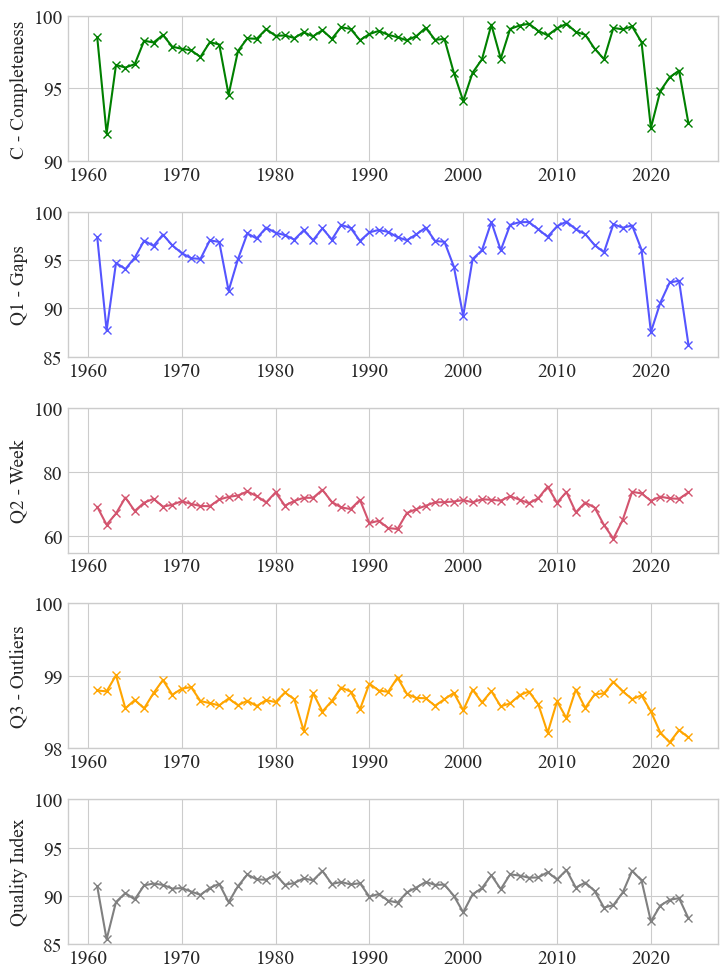

In [23]:
# Calculate the average value of each parameter by year
df_avg_params = df_qc_info.groupby('year').agg({
    'p_availability': 'mean',
    'q1_gaps': 'mean',
    'q2_week': 'mean',
    'q3_outliers': 'mean',
    'quality_index': 'mean'
}).reset_index()

# Create a figure and axis with a custom size
fig, ax = plt.subplots(5, 1, figsize=(7.5, 10), sharex=True)

# Plot each parameter
ax0 = ax[0]
ax0.plot(df_avg_params['year'], df_avg_params['p_availability'], marker='x', color='g', label='C - Completeness')
ax0.set_ylim(90, 100)
ax0.set_ylabel('C - Completeness')
ax0.grid(True)

# lines, labels = ax0.get_legend_handles_labels()
# legend = ax0.legend(lines , labels + labels, loc='lower center')
# legend.set_frame_on(True)  # Ensure frame is visible
# frame = legend.get_frame()
# frame.set_facecolor('white')
# frame.set_edgecolor('grey')
# frame.set_linewidth(0.5)


ax1 = ax[1]
ax1.plot(df_avg_params['year'], df_avg_params['q1_gaps'], marker='x', color='#5555ff', label='Q1 - Gaps')
ax1.set_ylabel('Q1 - Gaps')
ax1.set_ylim(85, 100)
ax1.grid(True)

# lines, labels = ax1.get_legend_handles_labels()
# legend = ax1.legend(lines , labels + labels, loc='lower center')
# legend.set_frame_on(True)  # Ensure frame is visible
# frame = legend.get_frame()
# frame.set_facecolor('white')
# frame.set_edgecolor('grey')
# frame.set_linewidth(0.5)


ax2 = ax[2]
ax2.plot(df_avg_params['year'], df_avg_params['q2_week'], marker='x', color='#d3546e', label='Q2 - Week')
ax2.set_ylabel('Q2 - Week')
ax2.set_ylim(55, 100)
ax2.grid(True)

# lines, labels = ax2.get_legend_handles_labels()
# legend = ax2.legend(lines , labels + labels, loc='upper center')
# legend.set_frame_on(True)  # Ensure frame is visible
# frame = legend.get_frame()
# frame.set_facecolor('white')
# frame.set_edgecolor('grey')
# frame.set_linewidth(0.5)


ax3 = ax[3]
ax3.plot(df_avg_params['year'], df_avg_params['q3_outliers'], marker='x', color='orange', label='Q3 - Outliers')
ax3.set_ylim(98, 100)
ax3.set_ylabel('Q3 - Outliers')
ax3.grid(True)

# lines, labels = ax3.get_legend_handles_labels()
# legend = ax3.legend(lines , labels + labels, loc='upper center')
# legend.set_frame_on(True)  # Ensure frame is visible
# frame = legend.get_frame()
# frame.set_facecolor('white')
# frame.set_edgecolor('grey')
# frame.set_linewidth(0.5)

ax4 = ax[4]
ax4.set_ylim(85, 100)
ax4.plot(df_avg_params['year'], df_avg_params['quality_index'], marker='x', color='grey', label='Quality Index')
# ax4.set_xlabel('Year')
ax4.set_ylabel('Quality Index')
ax4.grid(True)

# lines, labels = ax4.get_legend_handles_labels()
# legend = ax4.legend(lines , labels + labels, loc='upper center')
# legend.set_frame_on(True)  # Ensure frame is visible
# frame = legend.get_frame()
# frame.set_facecolor('white')
# frame.set_edgecolor('grey')
# frame.set_linewidth(0.5)

# Show xticks on all subplots
for a in ax:
    a.label_outer()  # Hides labels except for the last subplot but keeps ticks visible
    a.tick_params(axis='x', which='both', labelbottom=True)  # Ensure xticks are visible
    
plt.tight_layout()
plt.savefig('./figures/quality_index_avg_year.tiff', dpi = 300)
plt.show()
plt.close()

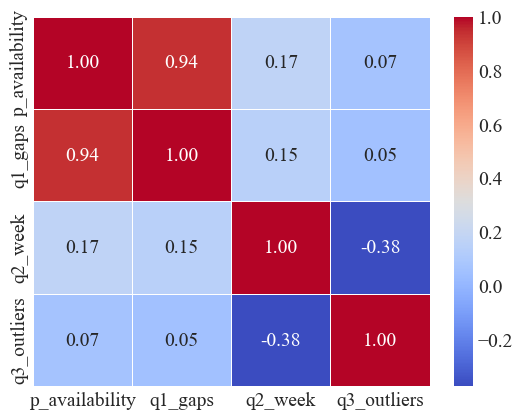

In [24]:
# Select relevant columns for the heatmap
heatmap_data = df_qc_info[['p_availability', 'q1_gaps', 'q2_week', 'q3_outliers']]

# Calculate the correlation matrix
corr = heatmap_data.corr()

# Create a heatmap
# plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Heatmap of df_qc_info Parameters')
plt.show()

In [25]:
df_qc_count = df_qc_info.groupby('quality_label').size().reset_index(name='count')
df_qc_count['percent'] = (df_qc_count['count'] / df_qc_count['count'].sum()) * 100
df_qc_count

,quality_label,count,percent
0,1 - Excellent Quality,277297,80.174228
1,2 - Good Quality,24993,7.226167
2,3 - Acceptable Quality,5979,1.728694
3,4 - Low Quality,31300,9.049695
4,5 - Very Low Quality,6299,1.821215


In [26]:
df_qc_avg = df_qc_info.groupby('quality_label').agg({'p_availability': 'mean'
                                                     , 'q1_gaps':'mean'
                                                     , 'q2_week':'mean'
                                                     , 'q3_outliers':'mean'
                                                     }).reset_index()
df_qc_avg

,quality_label,p_availability,q1_gaps,q2_week,q3_outliers
0,1 - Excellent Quality,99.997645,99.993103,79.105136,98.486915
1,2 - Good Quality,99.930966,99.790921,54.116358,99.193965
2,3 - Acceptable Quality,98.719868,95.840249,40.065608,99.291802
3,4 - Low Quality,91.471958,80.337439,16.257813,99.623118
4,5 - Very Low Quality,24.978982,0.041236,34.403758,98.286403


In [27]:
df_qc_min = df_qc_info.groupby('quality_label').agg({'p_availability': 'min'
                                                     , 'q1_gaps':'min'
                                                     , 'q2_week':'min'
                                                     , 'q3_outliers':'min'
                                                     }).reset_index()
df_qc_min

,quality_label,p_availability,q1_gaps,q2_week,q3_outliers
0,1 - Excellent Quality,99.178082,97.513812,60.000000,74.794521
1,2 - Good Quality,95.068493,84.438040,40.000000,69.589041
2,3 - Acceptable Quality,90.136986,67.173252,20.026785,79.452055
3,4 - Low Quality,8.469945,0.000000,0.000000,76.375405
4,5 - Very Low Quality,0.273224,0.000000,0.000000,0.000000


In [28]:
df_qc_max = df_qc_info.groupby('quality_label').agg({'p_availability': 'max'
                                                     , 'q1_gaps':'max'
                                                     , 'q2_week':'max'
                                                     , 'q3_outliers':'max'
                                                     }).reset_index()
df_qc_max

,quality_label,p_availability,q1_gaps,q2_week,q3_outliers
0,1 - Excellent Quality,100.000000,100.000000,100.000000,100.0
1,2 - Good Quality,100.000000,100.000000,96.602646,100.0
2,3 - Acceptable Quality,100.000000,100.000000,97.200823,100.0
3,4 - Low Quality,100.000000,100.000000,100.000000,100.0
4,5 - Very Low Quality,78.961749,20.069204,100.000000,100.0


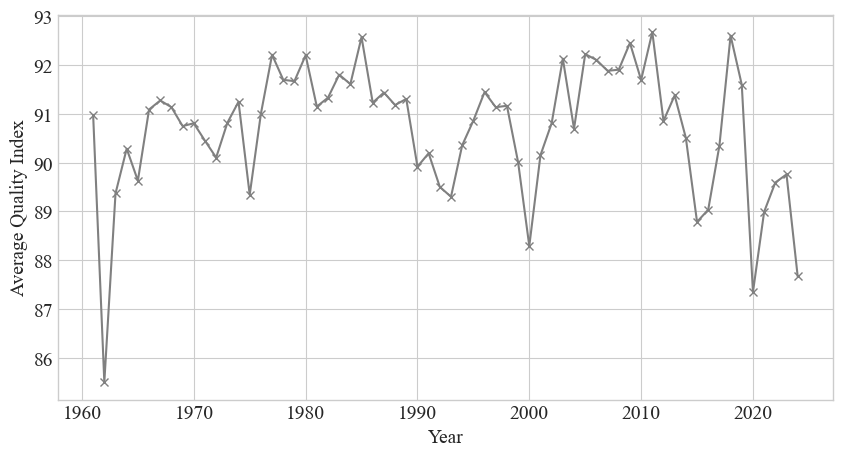

In [29]:
# Calculate the average quality index over the years
df_avg_quality_index = df_qc_info.groupby('year')['quality_index'].mean().reset_index()

# Create a figure and axis with a custom size
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the average quality index over the years
ax.plot(df_avg_quality_index['year'], df_avg_quality_index['quality_index'], marker='x', color='grey', label='Average Quality Index')

# Add labels, title, and grid
ax.set_xlabel('Year')
ax.set_ylabel('Average Quality Index')
# ax.set_title('Average Quality Index Over the Years')
ax.grid(True)

plt.savefig('./figures/quality_index_over_the_years.tiff', dpi=1800, bbox_inches='tight')
plt.show()
plt.close()

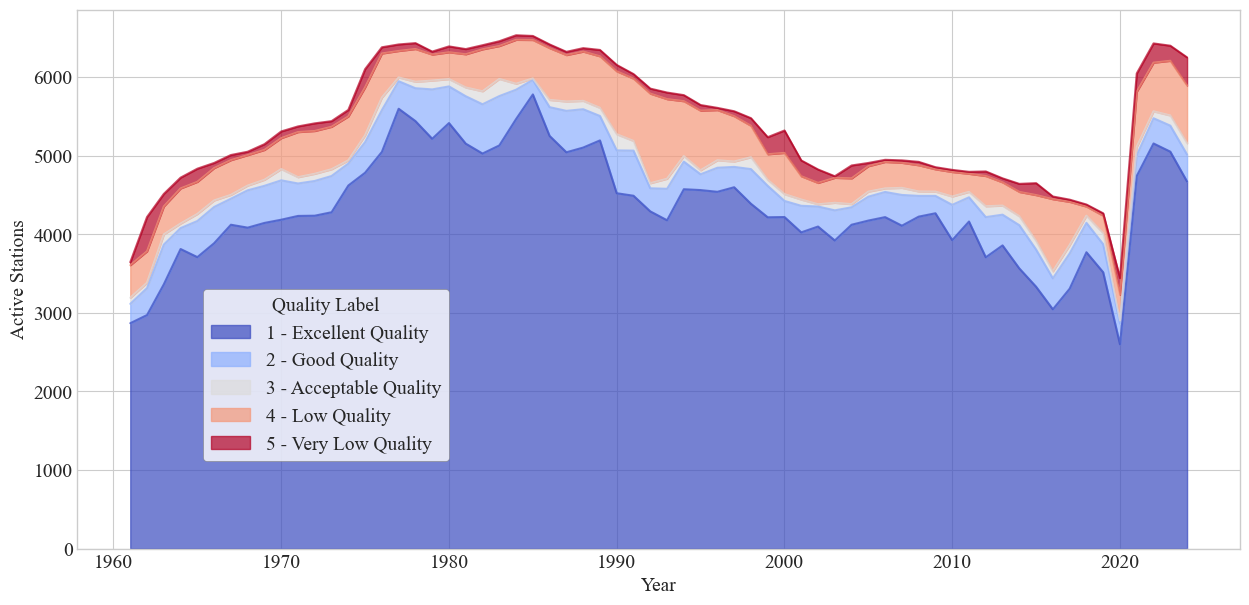

In [30]:

# Group by year and quality label to get the count of active stations
df_active_stations = df_qc_info.groupby(['year', 'quality_label']).size().unstack(fill_value=0)

# Create a stacked area plot with updated figure size
fig, ax = plt.subplots(figsize=(15, 7))

# Use a colorblind-friendly colormap
df_active_stations.plot(kind='area', stacked=True, ax=ax, colormap='coolwarm', alpha=0.7)

# Add labels, title, and grid
ax.set_xlabel('Year')
ax.set_ylabel('Active Stations')
# ax.set_title('Count of Active Stations by Year and Quality Label')
ax.grid(True)

# Modify the EXISTING legend from pandas plot
legend = ax.legend()
legend.set_title('Quality Label')  # Set title
legend.set_bbox_to_anchor((0.1, 0.5))  # Set legend position
legend.set_frame_on(True)  # Ensure frame is visible

# Customize frame properties
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')
frame.set_linewidth(0.5)

plt.savefig('./figures/active_stations_by_year_and_quality_label.tiff', dpi=1800, bbox_inches='tight')

plt.show()
plt.close()